# Finite Element Analysis - Plate with Circular Hole under Tension

This notebook uses the finite element method to analyze stress distribution in a plate with a circular hole under tensile loading, and studies convergence through mesh refinement.
## Governing Equations

**Strong form (2D linear elasticity, plane strain).** On the domain $\Omega$ (quarter plate with a circular hole) with boundary $\partial\Omega = \Gamma_g \cup \Gamma_t$:

- Equilibrium:
$$\nabla \cdot \boldsymbol{\sigma} + \mathbf{b} = \mathbf{0} \quad \text{in } \Omega$$

- Strain–displacement (small strain):
$$\boldsymbol{\varepsilon} = \tfrac{1}{2}\left(\nabla \mathbf{u} + \nabla \mathbf{u}^T\right)$$

- Constitutive law (plane strain, isotropic linear elastic):
$$\boldsymbol{\sigma} = \mathbf{D}\,\boldsymbol{\varepsilon}, \qquad
\mathbf{D} = \begin{bmatrix} \lambda+2\mu & \lambda & 0 \\ \lambda & \lambda+2\mu & 0 \\ 0 & 0 & \mu \end{bmatrix}$$
where the Lamé constants are $\mu = \dfrac{E}{2(1+\nu)}$ and $\lambda = \dfrac{E\nu}{(1+\nu)(1-2\nu)}$ (this is exactly `D_mat` built in Section 2).

- Boundary conditions:
$$\mathbf{u} = \bar{\mathbf{u}} \text{ on } \Gamma_g, \qquad \boldsymbol{\sigma}\cdot\mathbf{n} = \bar{\mathbf{t}} \text{ on } \Gamma_t$$
Here $\Gamma_g$ enforces the symmetry conditions $u_y = 0$ on $y=0$ and $u_x = 0$ on $x=0$, and $\Gamma_t$ is loaded with the Kirsch analytical traction ($f_{srr}$, $f_{stt}$, $f_{srt}$ from Section 3) on the outer edges $x=L$ and $y=L$, with $\mathbf{b}=\mathbf{0}$ (no body force).

**Weak form.** Find $\mathbf{u} \in \mathcal{V}$ such that for all admissible virtual displacements $\mathbf{w} \in \mathcal{V}_0$:
$$\int_\Omega \boldsymbol{\varepsilon}(\mathbf{w})^T \mathbf{D}\,\boldsymbol{\varepsilon}(\mathbf{u})\, d\Omega
= \int_\Omega \mathbf{w}^T \mathbf{b}\, d\Omega + \int_{\Gamma_t} \mathbf{w}^T \bar{\mathbf{t}}\, d\Gamma$$


## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

## 2. Physical and Material Parameters

Set elastic modulus, Poisson's ratio, geometric parameters, and construct the stiffness matrix for plane strain problem.

In [2]:
# Physical and material parameters
E   = 1.0e3       # Elastic modulus
nu  = 0.30        # Poisson's ratio
Tx  = 1.0         # Tensile load
R   = 1.0         # Hole radius
L   = 5.0         # Plate boundary size
ndof = 2          # Degrees of freedom per node
ncoord = 2        # Coordinates per node
eleType = 4       # Element type (quadrilateral)

# Plane-strain elastic constitutive matrix
mu = E / (2.0 * (1.0 + nu))
lambda_ = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))

D_mat = np.array([
    [lambda_ + 2.0 * mu, lambda_,             0.0],
    [lambda_,             lambda_ + 2.0 * mu, 0.0],
    [0.0,                 0.0,                 mu]
])



## 3. Analytical Stress and Body Force Functions

Define the analytical solution for the plate with hole problem (stress components in polar coordinates).

In [3]:
def f_srr_plate_with_hole(rr, th):
    """Radial stress analytical solution"""
    return 0.5*Tx*(1.0-rr**2.0) + 0.5*Tx*(1.0-4.0*rr**2.0+3.0*rr**4.0)*np.cos(2.0*th)

def f_stt_plate_with_hole(rr, th):
    """Circumferential stress analytical solution"""
    return 0.5*Tx*(1.0+rr**2.0) - 0.5*Tx*(1.0+3.0*rr**4.0)*np.cos(2.0*th)

def f_srt_plate_with_hole(rr, th):
    """Shear stress analytical solution"""
    return -0.5*Tx*(1.0+2.0*rr**2.0-3.0*rr**4.0)*np.sin(2.0*th)
def body_force_plate_with_hole(x, y):
    """Return the body-force components at the physical point (x, y)."""
    bx = 0.0
    by = 0.0
    return np.array([bx, by])

## 4. Mesh Generation Function

Generate structured mesh for plate with hole, including node coordinates, element connectivity, and boundary conditions.

In [4]:
# Quarter plate with a circular hole: x >= 0, y >= 0
# The outer edges receive the analytical traction from the plate-with-hole solution.
def get_mesh_platehole(nelem_1D, R, L):
    nnode_1D = nelem_1D + 1
    nnode = nnode_1D**2 * 2 - nnode_1D
    nelem = nelem_1D**2 * 2
    tolerance = 1.0e-10

    th = np.linspace(0.0, np.pi / 4.0, nnode_1D)
    x_1, y_1, x_2, y_2 = [], [], [], []

    for irow in range(nnode_1D):
        x_row = np.linspace(np.cos(th[irow]) * R, L, nnode_1D)
        y_row = np.linspace(np.sin(th[irow]) * R, L / nelem_1D * irow, nnode_1D)
        x_1.extend(x_row)
        y_1.extend(y_row)

        if irow != nnode_1D - 1:
            x_2 = list(y_row) + x_2
            y_2 = list(x_row) + y_2

    coords = np.array([x_1 + x_2, y_1 + y_2])

    connect = np.zeros((4, nelem), dtype=int)
    rowcount = 0
    for elementcount in range(nelem):
        connect[0, elementcount] = elementcount + rowcount
        connect[1, elementcount] = elementcount + rowcount + 1
        connect[2, elementcount] = elementcount + rowcount + nnode_1D + 1
        connect[3, elementcount] = elementcount + rowcount + nnode_1D

        if (elementcount + 1) % nelem_1D == 0:
            rowcount += 1

    # Symmetry boundary conditions: u_y(x, 0) = 0 and u_x(0, y) = 0.
    nodes_on_x_axis = np.where(np.isclose(coords[1, :], 0.0, atol=tolerance))[0]
    nodes_on_y_axis = np.where(np.isclose(coords[0, :], 0.0, atol=tolerance))[0]
    nfix = len(nodes_on_x_axis) + len(nodes_on_y_axis)
    fixnodes = np.zeros((3, nfix), dtype=int)
    fixnodes[0, :len(nodes_on_x_axis)] = nodes_on_x_axis
    fixnodes[1, :len(nodes_on_x_axis)] = 1
    fixnodes[0, len(nodes_on_x_axis):] = nodes_on_y_axis
    fixnodes[1, len(nodes_on_x_axis):] = 0

    # Q4 local faces, listed counter-clockwise around the reference element.
    q4_faces = {
        0: np.array([0, 1]),
        1: np.array([1, 2]),
        2: np.array([2, 3]),
        3: np.array([3, 0]),
    }

    # Each entry defines a physical traction boundary and its outward normal.
    traction_boundaries = [
        {"coordinate": 0, "value": L, "normal": np.array([1.0, 0.0])},
        {"coordinate": 1, "value": L, "normal": np.array([0.0, 1.0])},
    ]

    loaded_faces = []
    for element_index, element in enumerate(connect.T):
        for face, local_nodes in q4_faces.items():
            face_nodes = element[local_nodes]

            for boundary in traction_boundaries:
                face_coordinates = coords[boundary["coordinate"], face_nodes]
                if np.all(np.isclose(face_coordinates, boundary["value"], atol=tolerance)):
                    loaded_faces.append((element_index, face, boundary["normal"]))

    dloads = np.zeros((4, len(loaded_faces)))
    for load_index, (element_index, face, normal) in enumerate(loaded_faces):
        element = connect[:, element_index]
        boundary_nodes = element[q4_faces[face]]

        x = 0.5 * (coords[:, boundary_nodes[0]] + coords[:, boundary_nodes[1]])
        r = np.sqrt(x[0]**2 + x[1]**2)
        th = np.arctan2(x[1], x[0])

        srr = f_srr_plate_with_hole(R / r, th)
        stt = f_stt_plate_with_hole(R / r, th)
        srt = f_srt_plate_with_hole(R / r, th)
        RM = np.array([[np.cos(th), np.sin(th)],
                       [-np.sin(th), np.cos(th)]])
        stress = RM.T @ np.array([[srr, srt], [srt, stt]]) @ RM
        traction = stress @ normal

        dloads[0, load_index] = element_index
        dloads[1, load_index] = face
        dloads[2:4, load_index] = traction

    return nnode, coords.T, nelem, connect.T, fixnodes, dloads

## 5. Shape Functions and Derivatives (Q4 Element)

Four-node quadrilateral element shape functions and their partial derivatives.

In [5]:
def shapefunctions_q4(xi, eta):
    """Return Q4 shape functions and their parametric derivatives."""
    N = np.array([
        0.25 * (1 - xi) * (1 - eta),
        0.25 * (1 + xi) * (1 - eta),
        0.25 * (1 + xi) * (1 + eta),
        0.25 * (1 - xi) * (1 + eta)
    ])
    dNdxi = 0.25 * np.array([
        -(1 - eta),
        (1 - eta),
        (1 + eta),
        -(1 + eta)
    ])
    dNdeta = 0.25 * np.array([
        -(1 - xi),
        -(1 + xi),
        (1 + xi),
        (1 - xi)
    ])
    return N, dNdxi, dNdeta

## 6. Element Stiffness Matrix and Force Vector

Calculate element stiffness matrix using Gauss integration.

In [6]:
def get_element_k_and_f(coord, D_mat, gauss_points, gauss_weights, get_body_force):
    """Return the Q4 element stiffness matrix and body-force vector."""
    ke = np.zeros((8, 8))
    fe = np.zeros(8)

    for xi, weight_xi in zip(gauss_points, gauss_weights):
        for eta, weight_eta in zip(gauss_points, gauss_weights):

            # Shape functions and their parametric derivatives
            N, dNdxi, dNdeta = shapefunctions_q4(xi, eta)

            # Jacobian matrix 
            # [ \partial x/partial \xi             \partial x/partial \eta ]
            # [ \partial y/partial \xi             \partial y/partial \eta ]
            J = np.zeros((2, 2))
            x_gauss = 0
            y_gauss = 0
            for i in range(4):
                J[0, 0] += dNdxi[i] * coord[i, 0]
                J[0, 1] += dNdeta[i] * coord[i, 0]
                J[1, 0] += dNdxi[i] * coord[i, 1]
                J[1, 1] += dNdeta[i] * coord[i, 1]
                x_gauss += N[i] * coord[i, 0]
                y_gauss += N[i] * coord[i, 1]

            detJ = np.linalg.det(J)
            invJ = np.linalg.inv(J)

            # Compute the derivatives of shape functions with respect to physical coordinates
            dNdxy = invJ.T @ np.array([dNdxi, dNdeta])

            B = np.zeros((3, 8))
            N_matrix = np.zeros((2, 8))
            for i in range(4):
                B[0, 2 * i] = dNdxy[0, i]
                B[1, 2 * i + 1] = dNdxy[1, i]
                B[2, 2 * i] = dNdxy[1, i]
                B[2, 2 * i + 1] = dNdxy[0, i]
                N_matrix[0, 2 * i] = N[i]
                N_matrix[1, 2 * i + 1] = N[i]

            ke += B.T @ D_mat @ B * detJ * weight_xi * weight_eta

            # Physical coordinates of the Gauss point to evaluate the body force.
            body_force = get_body_force(x_gauss, y_gauss)
            fe += N_matrix.T @ body_force * detJ * weight_xi * weight_eta

    return ke, fe

## 7. Global Assembly and Solution

Assemble global stiffness matrix, apply boundary conditions, and solve the linear system.

In [7]:
def get_gauss_integration_points(number_gauss_points_in_one_direction):
    """Return Gauss-Legendre points and weights on the interval [-1, 1]."""
    if not isinstance(number_gauss_points_in_one_direction, int):
        raise TypeError("The number of Gauss points must be an integer.")
    if number_gauss_points_in_one_direction < 1:
        raise ValueError("The number of Gauss points must be at least 1.")

    return np.polynomial.legendre.leggauss(number_gauss_points_in_one_direction)


def get_global_stiffness_and_force(
    total_nodes, coords, total_element, elements, D_mat, gauss_points, gauss_weights, get_body_force
):
    """Assemble the global stiffness matrix K and body-force vector F."""
    degrees_of_freedom_per_node = 2
    K = np.zeros((degrees_of_freedom_per_node * total_nodes,
                  degrees_of_freedom_per_node * total_nodes))
    F = np.zeros(degrees_of_freedom_per_node * total_nodes)

    for e in range(total_element):
        # node IDs in the e-th element, like 1 3 5 6 
        element = elements[e]

        # node coordinates for the e-th element
        element_coordinates = coords[element]

        # calculate the elment k and f for the e-th element
        ke, fe = get_element_k_and_f(
            element_coordinates, D_mat, gauss_points, gauss_weights, get_body_force
        )

        for i in range(4):
            
            for dof_a in range(degrees_of_freedom_per_node):

                # global node id
                row = degrees_of_freedom_per_node * element[i] + dof_a

                # local node id
                local_dof_a = degrees_of_freedom_per_node * i + dof_a

                F[row] += fe[local_dof_a]

                for j in range(4):

                    for dof_b in range(degrees_of_freedom_per_node):

                        # global node id for the b-th local node
                        column = degrees_of_freedom_per_node * element[j] + dof_b

                        # local node id for the b-th local node
                        local_dof_b = degrees_of_freedom_per_node * j + dof_b

                        # local node id for the b-th local node
                        K[row, column] += ke[local_dof_a, local_dof_b]

    return K, F


def apply_traction_boundary_conditions(F, coords, elements, dloads, gauss_points, gauss_weights):
    """Add the edge-traction contributions to the global force vector F."""
    q4_face_nodes = {
        0: np.array([0, 1]),
        1: np.array([1, 2]),
        2: np.array([2, 3]),
        3: np.array([3, 0]),
    }

    for load_index in range(dloads.shape[1]):
        element_index = int(dloads[0, load_index])
        face = int(dloads[1, load_index])
        traction = dloads[2:4, load_index]
        element_nodes = elements[element_index]

        if face not in q4_face_nodes:
            raise ValueError(f"Unsupported Q4 element face: {face}")
        face_nodes = element_nodes[q4_face_nodes[face]]

        x1, y1 = coords[face_nodes[0]]
        x2, y2 = coords[face_nodes[1]]
        edge_length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        edge_jacobian = edge_length / 2.0

        for gauss_point, gauss_weight in zip(gauss_points, gauss_weights):
            N1 = 0.5 * (1 - gauss_point)
            N2 = 0.5 * (1 + gauss_point)

            F[2 * face_nodes[0]:2 * face_nodes[0] + 2] += N1 * traction * edge_jacobian * gauss_weight
            F[2 * face_nodes[1]:2 * face_nodes[1] + 2] += N2 * traction * edge_jacobian * gauss_weight

    return F


def apply_essential_boundary_conditions(K, F, fixnodes):
    """Apply prescribed nodal displacements to K and F."""
    degrees_of_freedom_per_node = 2

    for constraint_index in range(fixnodes.shape[1]):
        node = fixnodes[0, constraint_index]
        dof_component = fixnodes[1, constraint_index]
        prescribed_value = fixnodes[2, constraint_index]
        dof_index = degrees_of_freedom_per_node * node + dof_component

        K[dof_index, :] = 0.0
        K[:, dof_index] = 0.0
        K[dof_index, dof_index] = 1.0
        F[dof_index] = prescribed_value

    return K, F

## 8. Nodal Stress Calculation

Calculate stress components at nodes for subsequent plotting.

In [8]:
def compute_stress_at_nodes(coords, elements, U, D_mat):
    
    nnode = len(coords)
    sigma11 = np.zeros(nnode)
    sigma22 = np.zeros(nnode)
    sigma12 = np.zeros(nnode)
    node_count = np.zeros(nnode)
    
    # 参考单元的角点
    xi_corners = [-1.0, 1.0, 1.0, -1.0]
    eta_corners = [-1.0, -1.0, 1.0, 1.0]
    
    for elem in elements:
        elem_coords = coords[elem]
        elem_disp = np.zeros(8)
        for i in range(4):
            elem_disp[2*i] = U[2*elem[i]]
            elem_disp[2*i+1] = U[2*elem[i]+1]
        
        # 计算每个角点的应力
        for corner in range(4):
            xi = xi_corners[corner]
            eta = eta_corners[corner]
            
            N, dNdxi, dNdeta = shapefunctions_q4(xi, eta)
            J = np.zeros((2, 2))
            x_gauss = 0
            y_gauss = 0
            for i in range(4):
                J[0, 0] += dNdxi[i] * elem_coords[i, 0]
                J[0, 1] += dNdeta[i] * elem_coords[i, 0]
                J[1, 0] += dNdxi[i] * elem_coords[i, 1]
                J[1, 1] += dNdeta[i] * elem_coords[i, 1]
                x_gauss += N[i] * elem_coords[i, 0]
                y_gauss += N[i] * elem_coords[i, 1]
                
            detJ = np.linalg.det(J)
            invJ = np.linalg.inv(J)
            dNdxy = invJ.T @ np.array([dNdxi, dNdeta])
            # B矩阵
            B = np.zeros((3, 8))
            for i in range(4):
                B[0, 2*i] = dNdxy[0, i]
                B[1, 2*i+1] = dNdxy[1, i]
                B[2, 2*i] = dNdxy[1, i]
                B[2, 2*i+1] = dNdxy[0, i]
            
            # 计算应力
            strain = B @ elem_disp
            stress = D_mat @ strain
            
            # 累加到节点
            node_idx = elem[corner]
            sigma11[node_idx] += stress[0]
            sigma22[node_idx] += stress[1]
            sigma12[node_idx] += stress[2]
            node_count[node_idx] += 1
    
    # 平均
    sigma11 /= node_count
    sigma22 /= node_count
    sigma12 /= node_count
    
    return sigma11, sigma22, sigma12

## 9. Plotting Functions

Plot mesh and stress contours.

In [9]:
def plot_mesh(coords, elements, title="Mesh"):
    """Plot mesh"""
    plt.figure(figsize=(8, 8))

    # Plot elements
    for elem in elements:
        x = coords[elem[[0, 1, 2, 3, 0]], 0]
        y = coords[elem[[0, 1, 2, 3, 0]], 1]
        plt.plot(x, y, 'b-', linewidth=0.5)

    # Plot nodes
    plt.plot(coords[:, 0], coords[:, 1], 'ko', markersize=3)

    plt.axis('equal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


def get_plot_triangulation(coords, elements):
    """Split each Q4 element into two triangles for contour plotting."""
    triangles = []
    for element in elements:
        triangles.append([element[0], element[1], element[2]])
        triangles.append([element[0], element[2], element[3]])
    return mtri.Triangulation(coords[:, 0], coords[:, 1], triangles)


def plot_displacement_field(coords, elements, U):
    """Plot the x- and y-displacement components at the mesh nodes."""
    nodal_displacements = U.reshape(-1, 2)
    triangulation = get_plot_triangulation(coords, elements)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    displacement_plots = [
        (nodal_displacements[:, 0], r'$u_x$'),
        (nodal_displacements[:, 1], r'$u_y$')
    ]

    for axis, (displacement_component, title) in zip(axes, displacement_plots):
        contour = axis.tricontourf(
            triangulation, displacement_component, levels=20, cmap='jet'
        )
        axis.set_title(title)
        axis.set_aspect('equal')
        axis.set_xlabel('x')
        axis.set_ylabel('y')
        plt.colorbar(contour, ax=axis)

    plt.tight_layout()
    plt.show()


def plot_stress_contours(coords, elements, s11, s22, s12):
    """Plot stress contours"""
    triangulation = get_plot_triangulation(coords, elements)

    # Plot each stress component
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Sigma_11
    tcf1 = axes[0].tricontourf(triangulation, s11, levels=20, cmap='jet')
    axes[0].set_title(r'$\sigma_{11}$')
    axes[0].set_aspect('equal')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    plt.colorbar(tcf1, ax=axes[0])

    # Sigma_22
    tcf2 = axes[1].tricontourf(triangulation, s22, levels=20, cmap='jet')
    axes[1].set_title(r'$\sigma_{22}$')
    axes[1].set_aspect('equal')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    plt.colorbar(tcf2, ax=axes[1])

    # Sigma_12
    tcf3 = axes[2].tricontourf(triangulation, s12, levels=20, cmap='jet')
    axes[2].set_title(r'$\sigma_{12}$')
    axes[2].set_aspect('equal')
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('y')
    plt.colorbar(tcf3, ax=axes[2])

    plt.tight_layout()
    plt.show()

## 10. Main Program - Run the plate with a hole elasticity example 

In [10]:
# Plate with Hole FEM Analysis

# Material stiffness matrix from the parameter definitions in Section 2.

# Number of elements along each outer plate edge.
number_element_in_one_direction = 15
number_gauss_points_in_one_direction = 2

# Select the body-force function for this analysis.
get_body_force = body_force_plate_with_hole

# Generate the plate-with-hole mesh and boundary conditions.
total_nodes, coords, total_element, elements, fix_nodes, d_loads = get_mesh_platehole(
    number_element_in_one_direction, R, L 
)

# Define Gauss points and weights for domain and boundary integration.
gauss_points, gauss_weights = get_gauss_integration_points(
    number_gauss_points_in_one_direction
)

# Assemble the global stiffness matrix K and force vector F.
K, F = get_global_stiffness_and_force(
    total_nodes, coords, total_element, elements, D_mat, gauss_points, gauss_weights, get_body_force
)

# Add traction forces to the global force vector.
F = apply_traction_boundary_conditions(
    F, coords, elements, d_loads, gauss_points, gauss_weights
)

# Enforce prescribed displacements.
K, F = apply_essential_boundary_conditions(K, F, fix_nodes)

# Solve the linear system K U = F.
U = np.linalg.solve(K, F)

print(U)

[ 2.68843339e-03  0.00000000e+00  2.74543435e-03  0.00000000e+00
  2.79286121e-03  0.00000000e+00  2.86901571e-03  0.00000000e+00
  2.97475402e-03  0.00000000e+00  3.10495608e-03  0.00000000e+00
  3.25445660e-03  0.00000000e+00  3.41907635e-03  0.00000000e+00
  3.59561300e-03  0.00000000e+00  3.78164252e-03  0.00000000e+00
  3.97532572e-03  0.00000000e+00  4.17525666e-03  0.00000000e+00
  4.38035128e-03  0.00000000e+00  4.58976776e-03  0.00000000e+00
  4.80285027e-03  0.00000000e+00  5.01909032e-03  0.00000000e+00
  2.68441484e-03 -4.42005141e-05  2.73873637e-03 -1.69494577e-05
  2.78512152e-03 -1.18093456e-05  2.86101258e-03 -1.46706868e-05
  2.96685798e-03 -2.08404306e-05  3.09734208e-03 -2.84644547e-05
  3.24720238e-03 -3.67306215e-05  3.41221033e-03 -4.52612887e-05
  3.58913872e-03 -5.38763654e-05  3.77555134e-03 -6.24912301e-05
  3.96960356e-03 -7.10696981e-05  4.16988746e-03 -7.96015251e-05
  4.37531871e-03 -8.80916933e-05  4.58505573e-03 -9.65558525e-05
  4.79844262e-03 -1.05019

## 11. Visualization of the mesh, displacement Field, stress field

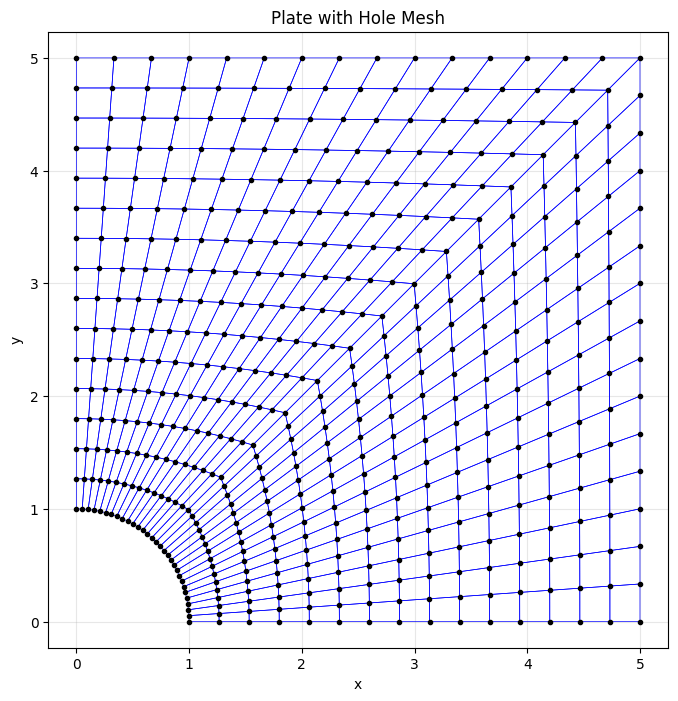

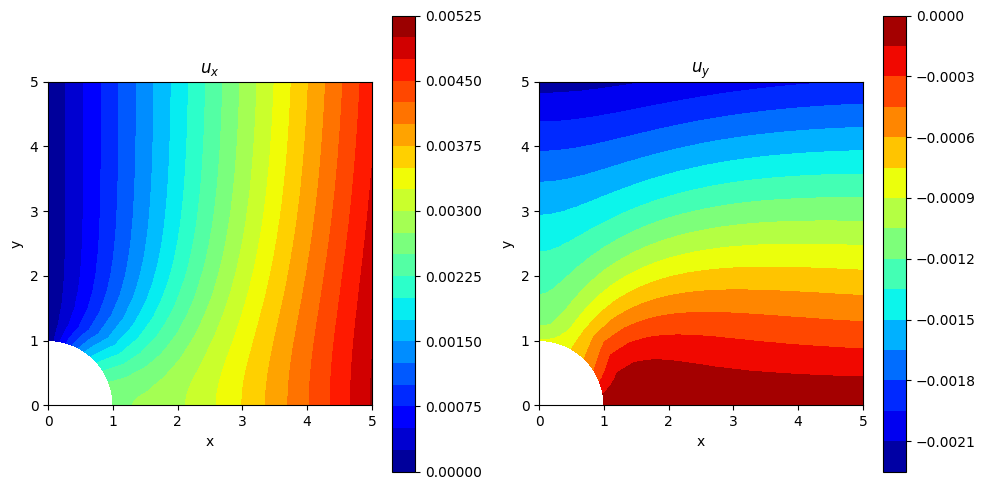

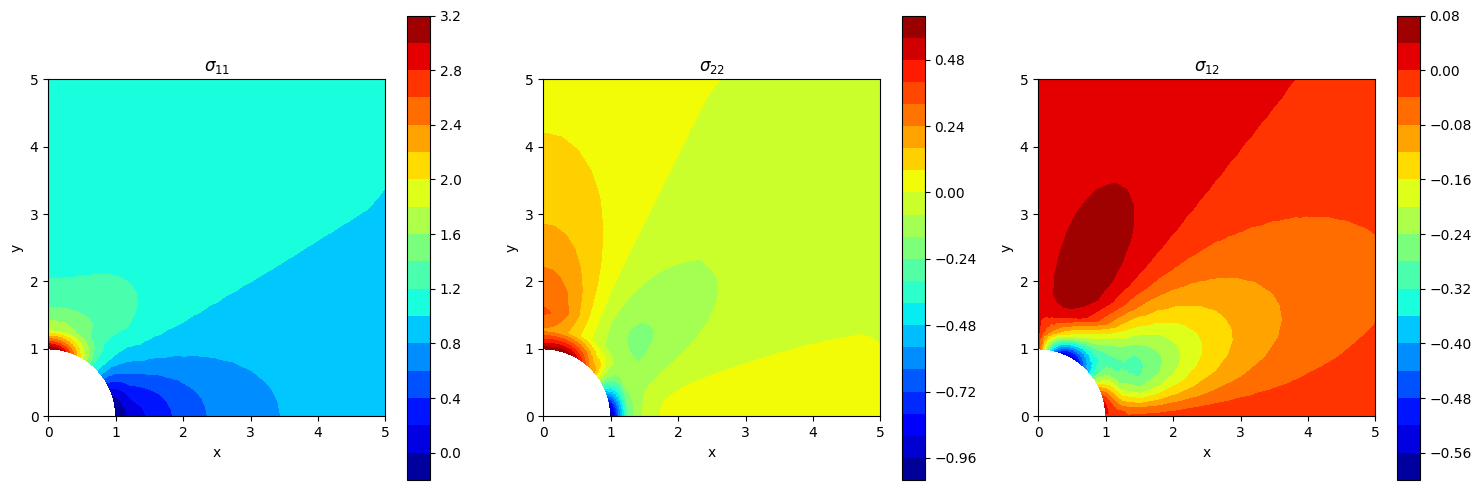

In [11]:
# Mesh visualization.
plot_mesh(coords, elements, "Plate with Hole Mesh")

# Displacement-component contours.
plot_displacement_field(coords, elements, U)

# Recover nodal stresses from the FEM displacement solution.
sigma11, sigma22, sigma12 = compute_stress_at_nodes(coords, elements, U, D_mat)

# Stress-field visualization.
plot_stress_contours(coords, elements, sigma11, sigma22, sigma12)

## 11. Energy Norm Error Calculation

Calculate energy norm error by comparing FEM solution with analytical solution.

In [12]:
def calculate_energy_norm_error(coords, elements, U, D_mat):
    
    print("\n===== Calculate error norm =====")
    
    # Gauss points and weights
    gauss_pts = [-1/np.sqrt(3), 1/np.sqrt(3)]
    weights = [1.0, 1.0]
    
    enorm2 = 0.0  # Square of the energy norm error
    
    
    S = np.linalg.inv(D_mat)
    print(f" S = \n{S}\n")
    
    # Loop over each element
    for elem_idx, elem in enumerate(elements):
        elem_coords = coords[elem]
        elem_disp = np.zeros(8)
        for i in range(4):
            elem_disp[2*i] = U[2*elem[i]]
            elem_disp[2*i+1] = U[2*elem[i]+1]
        
        # Integrate over each Gauss point within the element
        for xi in gauss_pts:
            for eta in gauss_pts:
                # Shape functions and their derivatives
                N, dNdxi, dNdeta = shapefunctions_q4(xi, eta)
                
                # Jacobian matrix
                J = np.array([dNdxi, dNdeta]) @ elem_coords
                detJ = np.linalg.det(J)
                invJ = np.linalg.inv(J)
                dNdxy = invJ @ np.array([dNdxi, dNdeta])
                
                
                B = np.zeros((3, 8))
                for i in range(4):
                    B[0, 2*i] = dNdxy[0, i]
                    B[1, 2*i+1] = dNdxy[1, i]
                    B[2, 2*i] = dNdxy[1, i]
                    B[2, 2*i+1] = dNdxy[0, i]
                
                
                strain_fem = B @ elem_disp
                
                
                x_gp = N @ elem_coords[:, 0]
                y_gp = N @ elem_coords[:, 1]
                
                
                r = np.sqrt(x_gp**2 + y_gp**2)
                if r < R:  # Avoid calculation inside the circular hole
                    r = R
                th = np.arctan2(y_gp, x_gp)
                
               
                srr = f_srr_plate_with_hole(R/r, th)
                stt = f_stt_plate_with_hole(R/r, th)
                srt = f_srt_plate_with_hole(R/r, th)
                
                
                RM = np.array([[np.cos(th), np.sin(th)], 
                               [-np.sin(th), np.cos(th)]])
                
                
                stress_polar = np.array([[srr, srt], [srt, stt]])
                stress_cart = RM.T @ stress_polar @ RM
                stress_exact = np.array([stress_cart[0,0], stress_cart[1,1], stress_cart[0,1]])
                
                
                strain_exact = S @ stress_exact
                
                
                strain_error = strain_fem - strain_exact
                
                
                contribution = strain_error @ D_mat @ strain_error * detJ * weights[0] * weights[1]
                enorm2 += contribution
                
                
                if elem_idx % 100 == 0 and xi == gauss_pts[0] and eta == gauss_pts[0]:
                    print(f"Element {elem_idx}, Gauss point ({xi:.2f},{eta:.2f}):")
                    print(f"  Strain error: {strain_error}")
                    print(f"  Contribution: {contribution:.6f}, Cumulative energy error squared: {enorm2:.6f}\n")
    
    # Calculate the energy norm error (square root)
    energy_norm_error = np.sqrt(enorm2)
    print(f"===== Error norm calculation completed =====")
    print(f"Total energy norm error = {energy_norm_error:.6f}\n")
    
    return energy_norm_error

## 12. Main Program 2 - Mesh Convergence Study

Perform calculations with different mesh densities and analyze convergence rate.

In [13]:
# Mesh refinement study
refinements = [10, 15, 20, 25]
h_vals = []
err_vals = []
number_gauss_points_in_one_direction = 2
get_body_force = body_force_plate_with_hole
gauss_points, gauss_weights = get_gauss_integration_points(
    number_gauss_points_in_one_direction
)

print("Energy Norm Error Analysis")
print("-" * 50)

for number_element_in_one_direction in refinements:
    # Generate mesh and boundary conditions.
    total_nodes, coords, total_element, elements, fix_nodes, d_loads = get_mesh_platehole(
        number_element_in_one_direction, R, L
    )

    # Mesh size.
    h = (L - R) / number_element_in_one_direction
    h_vals.append(h)

    # Assemble, apply boundary conditions, and solve.
    K, F = get_global_stiffness_and_force(
        total_nodes, coords, total_element, elements, D_mat, gauss_points, gauss_weights, get_body_force
    )
    F = apply_traction_boundary_conditions(
        F, coords, elements, d_loads, gauss_points, gauss_weights
    )
    K, F = apply_essential_boundary_conditions(K, F, fix_nodes)
    U = np.linalg.solve(K, F)

    # Calculate energy error norm.
    error = calculate_energy_norm_error(coords, elements, U, D_mat)
    err_vals.append(error)

    print(
        f"nelem_1D = {number_element_in_one_direction:3d}, "
        f"h = {h:.4f}, Energy norm error = {error:.6f}"
    )

Energy Norm Error Analysis
--------------------------------------------------

===== Calculate error norm =====
 S = 
[[ 0.00091 -0.00039  0.     ]
 [-0.00039  0.00091  0.     ]
 [ 0.       0.       0.0026 ]]

Element 0, Gauss point (-0.58,-0.58):
  Strain error: [-3.82992838e-06 -6.91636952e-06 -8.63601877e-05]
  Contribution: 0.000000, Cumulative energy error squared: 0.000000

Element 100, Gauss point (-0.58,-0.58):
  Strain error: [ 0.00026416 -0.00015488  0.00012657]
  Contribution: 0.000001, Cumulative energy error squared: 0.000038

===== Error norm calculation completed =====
Total energy norm error = 0.008577

nelem_1D =  10, h = 0.4000, Energy norm error = 0.008577

===== Calculate error norm =====
 S = 
[[ 0.00091 -0.00039  0.     ]
 [-0.00039  0.00091  0.     ]
 [ 0.       0.       0.0026 ]]

Element 0, Gauss point (-0.58,-0.58):
  Strain error: [-5.00175079e-05 -7.19070048e-06 -5.45617360e-05]
  Contribution: 0.000000, Cumulative energy error squared: 0.000000

Element 100

## 12. Plot Convergence Curve

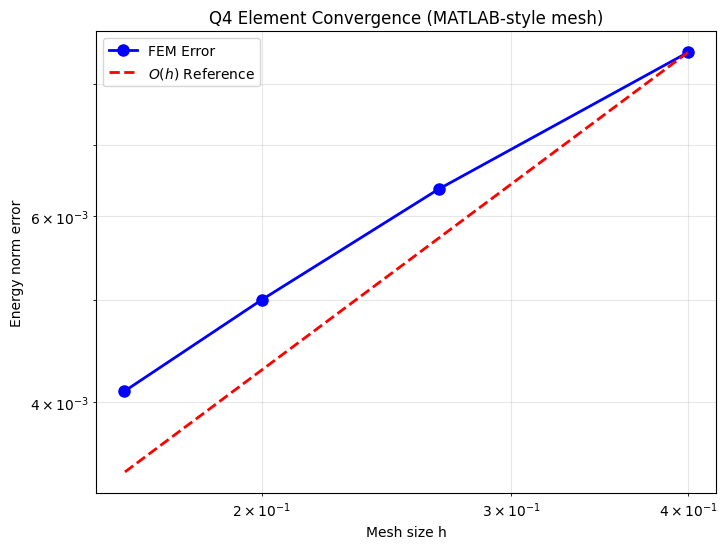


Convergence rate:
--------------------------------------------------
h: 0.4000 → 0.2667, Convergence rate = 0.7360
h: 0.2667 → 0.2000, Convergence rate = 0.8395
h: 0.2000 → 0.1600, Convergence rate = 0.8938


In [14]:
# Plot convergence curve
plt.figure(figsize=(8, 6))
plt.loglog(h_vals, err_vals, 'bo-', markersize=8, linewidth=2, label='FEM Error')

# Reference line
if len(h_vals) > 1:
    C = err_vals[0] / (h_vals[0]**1)
    h_ref = np.array([h_vals[0], h_vals[-1]])
    plt.loglog(h_ref, C * h_ref**1, 'r--', linewidth=2, label=r'$O(h)$ Reference')

plt.xlabel('Mesh size h')
plt.ylabel('Energy norm error')
plt.title('Q4 Element Convergence (MATLAB-style mesh)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()
print("\nConvergence rate:")
print("-" * 50)
for i in range(len(h_vals)-1):
    rate = np.log(err_vals[i+1]/err_vals[i]) / np.log(h_vals[i+1]/h_vals[i])
    print(f"h: {h_vals[i]:.4f} → {h_vals[i+1]:.4f}, Convergence rate = {rate:.4f}")